# Who is hit hardest by Inflation?
**Team Name:** Inflators
- Sanjana Devakumaran *(sanjud)*
- Sanjna Rachakonda *(sanjnarachakonda)*
- Tommy Ayers *(tlayers21)*
- Johnson Hwang *(hjohnson22)*
## Project Introduction
This project will investigate which groups are hit the hardest by inflation in the United States. We will first evaluate and compare inflation trends with wage changes across 5 income levels (quintiles) to understand how inflation affects different parts of the population. To this end, we compare CPI (consumer price index) and mean household income to discover if there has been a decline in purchasing power which in turn, leads to higher cost-of-living pressures. We analyze datasets containing data from 2005 to 2022. Building on these findings, we then investigate how income growth varies across states to understand which geographic regions are more affected by inflation. To achieve this, we compare mean state personal income with the Regional Price Parity (RPP), a measure of how expensive each state is relative to the national average, to compute a cost-of-living adjusted income for each state from 2008 to 2024.
## Research Questions
1. Does inflation affect low-income groups more severely than high-income ones?
2. Are certain states hit harder by inflation than others?


## Data Sources

#### Research Question 1
- [R-CPI-I: CPI Among Different Household Income Quintiles](https://www.bls.gov/cpi/research-series/r-cpi-i.htm) - U.S. Bureau of Labor Statistics
- [Mean Household Income by Quintile](https://taxpolicycenter.org/statistics/household-income-quintiles) - Urban-Brookings Tax Policy Center

#### Research Question 2
- [SQINC1: State Quarterly Personal Income](https://apps.bea.gov/itable/?ReqID=70&step=1&_gl=1*1dkdgnd*_ga*MTc4NDYyNDg2NS4xNzc0NTQzNzUx*_ga_J4698JNNFT*czE3NzczMzMwMTMkbzIkZzAkdDE3NzczMzMwMTMkajYwJGwwJGgw#eyJhcHBpZCI6NzAsInN0ZXBzIjpbMSwyOSwyNSwzMSwyNiwyNywzMCwzMF0sImRhdGEiOltbIlRhYmxlSWQiLCIzNiJdLFsiTWFqb3JfQXJlYSIsIjAiXSxbIlN0YXRlIixbIjAiXV0sWyJBcmVhIixbIlhYIl1dLFsiU3RhdGlzdGljIiwiMSJdLFsiVW5pdF9vZl9tZWFzdXJlIiwiTGV2ZWxzIl0sWyJZZWFyIixbIi0xIl1dLFsiWWVhckJlZ2luIiwiLTEiXSxbIlllYXJfRW5kIiwiLTEiXV19) - U.S. Bureau of Economic Analysis
- [SARPP: Regional Price Parities by State](https://apps.bea.gov/itable/?ReqID=70&step=1#eyJhcHBpZCI6NzAsInN0ZXBzIjpbMSwyOSwyNSwzMSwyNiwyNywzMF0sImRhdGEiOltbIlRhYmxlSWQiLCIxMDEiXSxbIk1ham9yX0FyZWEiLCIwIl0sWyJTdGF0ZSIsWyIwIl1dLFsiQXJlYSIsWyJYWCJdXSxbIlN0YXRpc3RpYyIsWyIxIl1dLFsiVW5pdF9vZl9tZWFzdXJlIiwiTGV2ZWxzIl0sWyJZZWFyIixbIi0xIl1dLFsiWWVhckJlZ2luIiwiLTEiXSxbIlllYXJfRW5kIiwiLTEiXV19) - U.S. Bureau of Economic Analysis

## Question 1

In Part 2, we want to investigate whether inflation affects low-income groups more severely than high-income ones. We will evaluate and compare CPI trends across 5 income quintiles with mean household income data to understand how inflation affects different parts of the population. We will be analyzing datasets containing data from 2005 to 2022.

The research question we want to answer in Part 2 is: "Does inflation affect low-income groups more severely than high-income ones?"

### Loading CPI Data (Income Quintile)

We begin by loading the R-CPI-I dataset, which measures Consumer Price Index (CPI) across different household income quintiles. CPI measures the average change over time in the prices paid by urban consumers for a market basket of consumer goods. Thus, this dataset allows us to compare how inflation changes over time for different income groups. We are intentionally skipping the first row because it contains context instead of column names. We use the first actual row as the header.

In [67]:
import pandas

r_cpi_i = pandas.read_excel("data/r-cpi-i-data.xlsx", skiprows=1, header=0)
r_cpi_i.head()

,Year,Month,R-CPI-I1,R-CPI-I2,R-CPI-I3,R-CPI-I4,R-CPI-I5
0,2005,12,100.000,100.000,100.000,100.000,100.000
1,2006,1,100.708,100.745,100.756,100.749,100.805
2,2006,2,100.822,100.908,100.933,100.965,101.123
3,2006,3,101.315,101.418,101.454,101.549,101.775
4,2006,4,102.123,102.268,102.290,102.413,102.594


### Loading Mean Income Data by Quintile

To better understand how inflation affects different groups and answer our research question, we also loaded a dataset containing average income values for each income quintile. This data shows that even if inflation rates are similar across groups, lower-income households may be more affected because they have less income to account for rising costs. This dataset will also later allow us to compare inflation trends with income levels. The dataset is loaded directly from an Excel file with standard column headers.

In [68]:
income_quintiles = pandas.read_excel("data/mean_income_quintiles.xlsx", header=0)
income_quintiles.head()

,Year,Income-1,Income-2,Income-3,Income-4,Income-5
0,2005,10660,27360,46300,72830,159580
1,2006,11350,28780,48220,76330,168170
2,2007,11550,29440,49970,79110,167970
3,2008,11660,29520,50130,79760,171060
4,2009,11550,29260,49530,78690,170840


In order to properly assess the monthly quintile data with the yearly income data, each quintile for each year is averaged so both datasets can be joined.

In [69]:
# 2005 is dropped since it only contained data for December and not all 12 months
yearly_r_cpi_i = r_cpi_i.drop('Month', axis=1).groupby('Year').mean().iloc[1:, :].reset_index()
yearly_r_cpi_i.head()

,Year,R-CPI-I1,R-CPI-I2,R-CPI-I3,R-CPI-I4,R-CPI-I5
0,2006,102.345000,102.394583,102.356667,102.445250,102.614333
1,2007,105.619917,105.436333,105.252917,105.313500,105.335833
2,2008,110.252333,109.873250,109.410750,109.340417,108.907500
3,2009,110.224750,109.472500,108.853917,108.843333,108.549417
4,2010,112.250917,111.551333,110.933667,110.745167,109.964167


### Joining CPI Data with Income Data

In order to better understand how inflation affects different income groups we combined the CPI dataset from earlier with the mean income dataset. We did a merge on the Year column because the CPI data is recorded monthly but the income data is yearly. In addition, matching by year allows us to align inflation values with their corresponding income levels. The join lets us compare inflation (CPI) with income levels to understand if lower income groups are hit harder from inflation and prepare the data for combined analysis. We used a left join to preserve all CPI observations while adding income information.

In [70]:
joined = pandas.merge(yearly_r_cpi_i, income_quintiles, left_on='Year', right_on='Year')
joined.head()

,Year,R-CPI-I1,R-CPI-I2,R-CPI-I3,R-CPI-I4,R-CPI-I5,Income-1,Income-2,Income-3,Income-4,Income-5
0,2006,102.345000,102.394583,102.356667,102.445250,102.614333,11350,28780,48220,76330,168170
1,2007,105.619917,105.436333,105.252917,105.313500,105.335833,11550,29440,49970,79110,167970
2,2008,110.252333,109.873250,109.410750,109.340417,108.907500,11660,29520,50130,79760,171060
3,2009,110.224750,109.472500,108.853917,108.843333,108.549417,11550,29260,49530,78690,170840
4,2010,112.250917,111.551333,110.933667,110.745167,109.964167,10990,28530,49170,78880,169390


### Reshaping Joined Data

After merging the CPI and income datasets, the data was still in a wide format and each quintile had its own set of columns. In order to make the dataset easier to analyze and visualize we converted it into a long format. Now, each row represents a single observation for a specific quintile, month, and year. Additionally, CPI and income values are stored in joint columns instead of separate columns per quintile. Converting to long format allowed us to more easily group and compare quintiles, create cleaner visualizations, and perform analysis across income groups. 

In [71]:
joined = pandas.merge(yearly_r_cpi_i, income_quintiles, on='Year')

dfs = []

# Concatenate data for each quintile into a long format DataFrame
for quintile in range(1, 6):
    temp = joined[['Year', f'R-CPI-I{quintile}', f'Income-{quintile}']].copy()
    
    temp = temp.rename(columns={f'R-CPI-I{quintile}': 'CPI',
                                f'Income-{quintile}': 'Income'})
    
    temp['Quintile'] = quintile
    dfs.append(temp)

joined_long = pandas.concat(dfs, ignore_index=True)
joined_long = joined_long[['Year', 'Quintile', 'CPI', 'Income']]

joined_long.head()

,Year,Quintile,CPI,Income
0,2006,1,102.345000,11350
1,2007,1,105.619917,11550
2,2008,1,110.252333,11660
3,2009,1,110.224750,11550
4,2010,1,112.250917,10990


### Calculating Real Income Growth

The original income data is not adjusted for inflation, so we cannot directly compare purchasing power across years. We use CPI to calculate real income using the following formula:

$$\text{Real Income} = \frac{\text{Nominal Income}}{\text{CPI}} \cdot 100$$

In [72]:
joined_long['Real Income'] = joined_long['Income'] / joined_long['CPI'] * 100
joined_long.head()

,Year,Quintile,CPI,Income,Real Income
0,2006,1,102.345000,11350,11089.940886
1,2007,1,105.619917,11550,10935.437524
2,2008,1,110.252333,11660,10575.739894
3,2009,1,110.224750,11550,10478.590335
4,2010,1,112.250917,10990,9790.565927


### Visualizing Real Income Across all 5 Quintiles

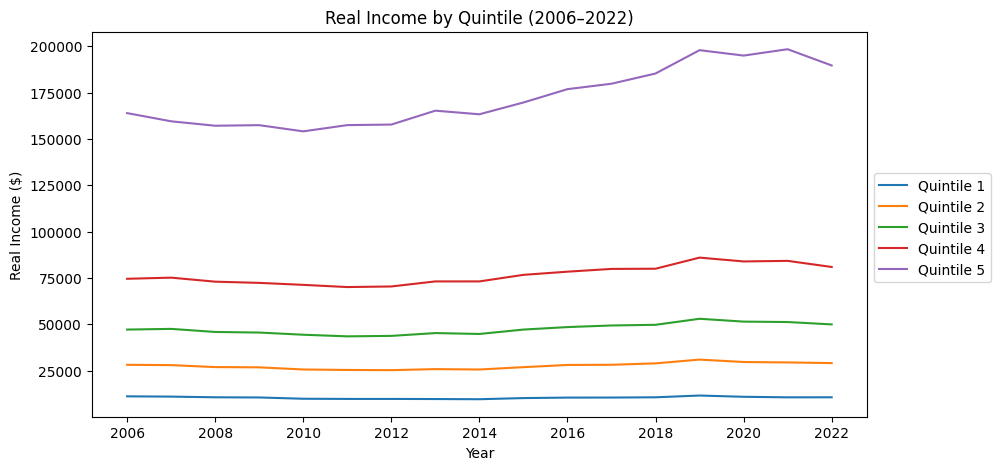

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot real income for each quintile over time
for quintile in range(1, 6):
    quintile_data = joined_long[joined_long['Quintile'] == quintile]
    plt.plot(
        quintile_data['Year'],
        quintile_data['Real Income'],
        label=f'Quintile {quintile}'
    )

plt.xlabel('Year')
plt.ylabel('Real Income ($)')
plt.title('Real Income by Quintile (2006–2022)')
plt.legend(bbox_to_anchor=(1, 0.65))
plt.show()

This line chart displays real income for each of the five quintiles from 2006 to 2022. We can observe several patterns from this data. The highest earners (Quintile 5) consistently holds the largest real income. Meanwhile, the lowest earners (quintile 1) is near the bottom for the entire time period. We can also observe that real incomes decline around 2020-2022 which reflects the effects of COVID-19 income related disruptions followed by a surge in inflation after the pandemic. The lowest quintile shows the least recovery which can lead us to assume that low-income households had the hardest time keeping up with rising prices during periods of high inflation. 

### Computing Real Income Growth

We will calculate the percent change in real income for each of the five quintiles in order to understand how purchasing power changes from year to year among the quintiles.

In [74]:
# Find the percent change every year for each quintile (2006 is excluded since it has no previous year to compare to)
joined_long['Real Income Growth'] = joined_long.groupby('Quintile')['Real Income'].pct_change() * 100
joined_long.head()

,Year,Quintile,CPI,Income,Real Income,Real Income Growth
0,2006,1,102.345000,11350,11089.940886,NaN
1,2007,1,105.619917,11550,10935.437524,-1.393185
2,2008,1,110.252333,11660,10575.739894,-3.289284
3,2009,1,110.224750,11550,10478.590335,-0.918608
4,2010,1,112.250917,10990,9790.565927,-6.566002


The last column measures the percent change in inflation-adjusted incomes within each quintile group. When the values are positive, this means that the real purchasing power grew. While negative values mean that purchasing power decreased. This is essential in comparing how well each income group keeps up with inflation over time. 

In [75]:
# Take the average percent change every year for each quintile and display it in a table
avg_growth = joined_long.groupby('Quintile')['Real Income Growth'].mean().rename('Average Growth (%)')
pandas.DataFrame(avg_growth)

,Average Growth (%)
Quintile,
1,-0.225693
2,0.251144
3,0.400327
4,0.555602
5,0.959302


This table presents the average annual real income growth rate for each of the five quintiles from 2006-2022. The results show that Quintile 1 (low earners) had a negative growth rate of -0.23% which means that their inflation-adjusted income declined every year. On the other hand, Quintile 5 (highest earners) had a positive growth rate of 0.96%. 

The data showing that the average real income growth increases consistently from lowest to highest quintile answers part of our first research question, suggesting inflation greater affects lower income groups.


### Visualizing Real Income Growth Across all 5 Quintiles

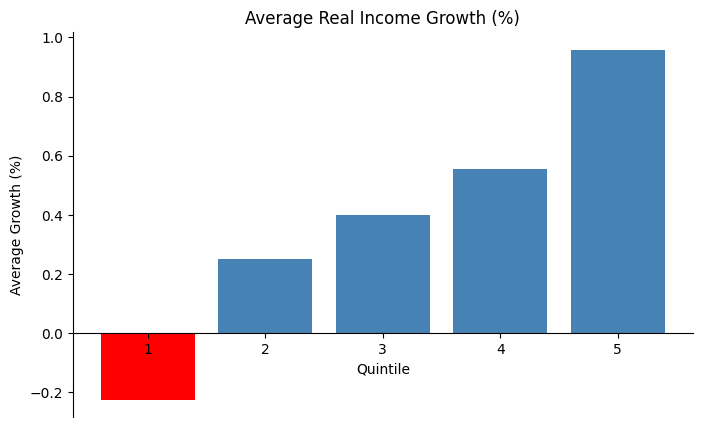

In [76]:
fig, ax = plt.subplots(figsize=(8,5))

colors = ['red' if x < 0 else 'steelblue' for x in avg_growth]
ax.bar(avg_growth.index, avg_growth, color=colors)

ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Quintile')
plt.ylabel('Average Growth (%)')
plt.title('Average Real Income Growth (%)')
plt.show()

This bar chart visualizes the differences in average real income growth between 5 quintiles. Negative average growth percents are red to represent a decrease in purchasing power while positive average growth percents are blue to represent an increase in purchasing power. Here we see that the only quintile that is red is the first quintile, which are groups in the bottom 20% of average household income. We also see that the jump from the fourth quintile to the fifth quintile is the biggest, showing how groups in the top 20% of average household income gained the most purchasing power.

### Procedural Changes & Iteration Reflection

Since Part 1, our project evolved in a few important ways. First, we refined our focus to be more data driven and specific to measurable economic indicators. Initially, our topic broadly explored \"who is affected by inflation,\" but we narrowed this down to analyzing income quintiles using CPI data and comparing it with wage/income trends over time.

## Research Question 1 Conclusion

In Part 2 of this project, we analyzed how inflation impacts different income groups by comparing CPI trends across income quintiles and aligning them with mean household income data from 2005 to 2022. Our findings show that although inflation increases at similar rates across all quintiles, lower income groups are more heavily affected because they have less income to absorb rising costs. This results in a greater loss of purchasing power for lower income households.

By reshaping and combining datasets, we were able to more effectively compare trends across income levels and better understand the relationship between inflation and income. Overall, our analysis supports the idea that inflation disproportionately impacts lower income groups.

In Part 3, we will extend this analysis to the state level by examining how RPP-adjusted income growth varies across states, and whether the same pattern of inequality holds geographically.

## Question 2
For Part 3, we want to investigate whether certain states are hit harder by inflation than others. We will evaluate and compare state income and state RPP (Regional Price Parity) to understand how inflation affects different states in the US. To this end, we plan on comparing each state's per capita personal income and its regional price parity to analyze the relationship between each state's income and the difference in price levels of goods and services across the United States. We will be analyzing datasets that contain data from 2008 to 2024.

The research question that we want to answer in Part 3 is: "Are certain states hit harder by inflation than others?"

### Loading State Income Data

We begin by loading the per capita personal income of each state from 2008 to 2024. This data allows us to see how income is distributed across the states and will be helpful to us later when we compare the regional price parities.

In [77]:
state_income = pandas.read_csv("data/state_real_income.csv", skiprows=3)
state_income = state_income.iloc[1:52, :]
state_income = state_income.drop(columns=['GeoFIPS']).rename(columns={'GeoName': 'State'})

state_income.head()

,State,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,Alabama,199198.2,199669.6,199704.6,201259.2,201300.9,201057.7,205206.7,215065.1,214790.7,220317.2,231135.3,235829.8,252590.1,266978.0,257105.1,260500.6,269312.8
2,Alaska,35505.2,35001.4,37959.5,39569.0,40280.7,39504.5,40924.0,41780.8,40448.8,40080.7,40871.3,41762.5,42897.5,42359.2,42901.3,42868.1,44609.1
3,Arizona,244718.7,232375.6,237887.2,247435.9,255416.2,257019.6,267057.4,281366.8,289173.6,304305.2,318094.0,333846.6,361459.0,395881.5,375776.1,388295.5,401032.4
4,Arkansas,117767.6,118635.8,117585.9,121265.3,126793.7,125232.1,130516.4,134891.0,136745.8,140148.5,145325.0,144940.8,154382.4,167035.5,162414.2,166040.2,170535.5
5,California,1602831.7,1566312.4,1623646.0,1688432.8,1752833.7,1754787.3,1834208.0,1950467.9,2031874.1,2072501.7,2116099.3,2211945.4,2371052.9,2480586.7,2314340.1,2355848.6,2485266.8


### Loading State RPP Data

Next, we will load the state regional price parities data from 2008 to 2024. This data shows us the regional price parity for each state, which measures the difference in price levels for goods and services expressed as a percentage of the overall national price level. For example, a RPP of 110 would indicate a 10% higher cost of living compared to the national average while a RPP of 90 would indicate the opposite.

In [78]:
state_rpp = pandas.read_csv("data/state_rpp.csv", skiprows=3)
state_rpp = state_rpp.iloc[1:52, :]
state_rpp = state_rpp.drop(columns=['GeoFIPS']).rename(columns={'GeoName': 'State'})

state_rpp.head()

,State,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,Alabama,88.901,87.786,89.783,90.011,90.559,90.324,90.175,89.741,90.609,90.065,87.378,88.303,87.569,88.062,88.021,89.097,88.823
2,Alaska,103.878,106.147,103.099,103.274,102.548,102.052,102.386,103.287,104.073,104.833,104.565,103.041,101.339,104.907,102.101,103.297,102.359
3,Arizona,102.504,102.865,100.558,99.083,98.050,98.441,97.944,97.865,98.622,97.915,97.381,97.779,99.203,96.600,99.992,100.742,100.677
4,Arkansas,88.096,86.364,88.561,89.383,89.394,89.493,89.395,89.013,89.298,88.561,87.144,87.744,88.165,88.902,86.913,86.810,86.937
5,California,111.220,110.696,109.703,109.503,109.666,109.667,109.926,110.685,109.956,110.998,111.882,111.134,111.944,111.918,112.591,112.195,110.720


### Joining State Income with State RPP

In order to better understand how inflation affects different states, we combined the state income dataset with the state RPP dataset. We did a merge on the State column to combine the income and rpp data for each state. In addition, matching by state allows us to align state income values with their corresponding RPP values. The join lets us compare each state's income with its corresponding RPP, understand if certain states are hit harder by inflation, and prepare the data for combined analysis.

In [79]:
joined_states = pandas.merge(state_income, state_rpp, on='State', suffixes=('_income', '_rpp'))
joined_states.head()

,State,2008_income,2009_income,2010_income,2011_income,2012_income,2013_income,2014_income,2015_income,2016_income,...,2015_rpp,2016_rpp,2017_rpp,2018_rpp,2019_rpp,2020_rpp,2021_rpp,2022_rpp,2023_rpp,2024_rpp
0,Alabama,199198.2,199669.6,199704.6,201259.2,201300.9,201057.7,205206.7,215065.1,214790.7,...,89.741,90.609,90.065,87.378,88.303,87.569,88.062,88.021,89.097,88.823
1,Alaska,35505.2,35001.4,37959.5,39569.0,40280.7,39504.5,40924.0,41780.8,40448.8,...,103.287,104.073,104.833,104.565,103.041,101.339,104.907,102.101,103.297,102.359
2,Arizona,244718.7,232375.6,237887.2,247435.9,255416.2,257019.6,267057.4,281366.8,289173.6,...,97.865,98.622,97.915,97.381,97.779,99.203,96.600,99.992,100.742,100.677
3,Arkansas,117767.6,118635.8,117585.9,121265.3,126793.7,125232.1,130516.4,134891.0,136745.8,...,89.013,89.298,88.561,87.144,87.744,88.165,88.902,86.913,86.810,86.937
4,California,1602831.7,1566312.4,1623646.0,1688432.8,1752833.7,1754787.3,1834208.0,1950467.9,2031874.1,...,110.685,109.956,110.998,111.882,111.134,111.944,111.918,112.591,112.195,110.720


### Reshaping Joined Data

After merging the income and RPP datasets, the data was still in a wide format and each year had its own set of columns. Similarly to what we did in Part 2, in order to make the dataset easier to analyze and visualize we converted it into a long format. Now, each row represents a single observation for a specific state. Additionally, the income and RPP values are stored in joint columns instead of separate columns per year. Converting to long format allows us to more easily group and compare states, create cleaner visualizations, and perform analysis across states.

In [80]:
dfs = []

for year in range(2008, 2025):
    temp = joined_states[['State', f'{year}_income', f'{year}_rpp']].copy()
    temp = temp.rename(columns={f'{year}_income': 'Income', f'{year}_rpp': 'RPP'})
    temp['Year'] = int(year)
    dfs.append(temp)

state_merged = pandas.concat(dfs, ignore_index=True)
state_merged = state_merged[['State', 'Year', 'Income', 'RPP']]

state_merged.head()

,State,Year,Income,RPP
0,Alabama,2008,199198.2,88.901
1,Alaska,2008,35505.2,103.878
2,Arizona,2008,244718.7,102.504
3,Arkansas,2008,117767.6,88.096
4,California,2008,1602831.7,111.220


### Calculating RPP Adjusted Income

To figure out the "real" purchasing power of each state, we calculated the RPP Adjusted Income by taking the state's income and dividing it by the RPP using the folowing formula:

$$\text{RPP Adjusted Income} = \frac{\text{Nominal Income}}{\text{RPP} / 100}$$

This reveals how much goods and services a specific income can buy in different states. We divide RPP by 100 because RPP is expressed as a percentage, so dividing by 100 converts it to a decimal multiplier.

In [81]:
state_merged['RPP_Adjusted_Income'] = state_merged['Income'] / (state_merged['RPP'] / 100)

state_merged.head()

,State,Year,Income,RPP,RPP_Adjusted_Income
0,Alabama,2008,199198.2,88.901,2.240674e+05
1,Alaska,2008,35505.2,103.878,3.417971e+04
2,Arizona,2008,244718.7,102.504,2.387406e+05
3,Arkansas,2008,117767.6,88.096,1.336810e+05
4,California,2008,1602831.7,111.220,1.441136e+06


### Calculating Average Adjusted Income and Average Growth

In this step, we are calculating the average adjusted income which represents the average purchasing power of a state and the average growth which represents the velocity of economic improvement (how fast "real income" is increasing year-over-year). This data will help us compare how well each state's residents are keeping up with the cost of living over time.

In [82]:
state_merged = state_merged.sort_values(['State', 'Year'])
state_merged['Adj_Income_Growth'] = state_merged.groupby('State')['RPP_Adjusted_Income'].pct_change() * 100

state_summary = state_merged.groupby('State').agg(
    Avg_Adj_Income=('RPP_Adjusted_Income', 'mean'),
    Avg_Growth=('Adj_Income_Growth', 'mean')
).dropna().reset_index()

state_summary.head()

,State,Avg_Adj_Income,Avg_Growth
0,Alabama,2.530705e+05,1.961570
1,Alaska,3.924837e+04,1.610850
2,Arizona,3.081485e+05,3.358255
3,Arkansas,1.587900e+05,2.464310
4,California,1.814027e+06,2.869502


### Final Data Cleaning

Finally, to prepare the data for plotting and further analysis, we normalize the average adjusted income and average growth that was calculated in the last step.

In [83]:
import sklearn.cluster
import numpy

quant = state_summary[['Avg_Adj_Income', 'Avg_Growth']]
norm = (quant - quant.mean()) / quant.std()
norm.head()

,Avg_Adj_Income,Avg_Growth
0,-0.205282,-0.532683
1,-0.811976,-1.059222
2,-0.049005,1.564172
3,-0.472791,0.222084
4,4.223740,0.830403


### K-Means Clustering

To group states with similar income and growth patterns, we use K-means clustering. This will allow us to identify which states are keeping up with the cost of living and which are falling behind. To determine the optimal number of clusters, we use the elbow method.

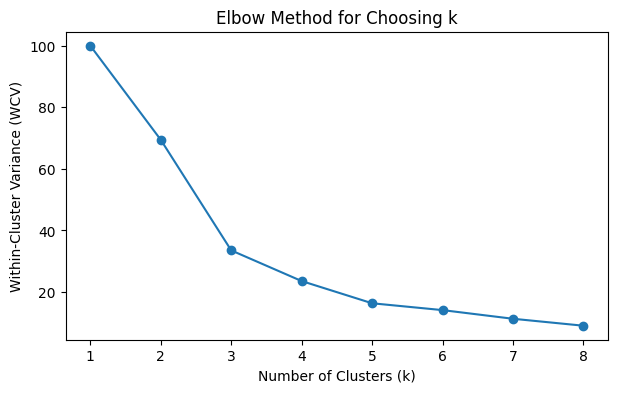

In [84]:
wcv = []
ks = range(1, 9)

for k in ks:
    km = sklearn.cluster.KMeans(n_clusters=k, random_state=42)
    km.fit_predict(norm)
    wcv.append(km.inertia_)

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.plot(ks, wcv, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Variance (WCV)')
plt.title('Elbow Method for Choosing k')
plt.show()

The elbow plot shows that the Within-Cluster Variance steeply drops from k=1 to k=3 and then the decrease is less steep. The "elbow" at k=3 indicates that 3 is the optimal number of clusters. If the number of clusters exceeded 3, it would make the results harder to interpret.

We will now run K-means with k=3 to group states into distinct clusters based on their average RPP-adjusted income and income growth.

In [85]:
km = sklearn.cluster.KMeans(n_clusters=3, random_state=42)
labels = km.fit_predict(norm)
state_summary['Cluster'] = labels

cluster_means = state_summary.groupby('Cluster')['Avg_Growth'].mean().sort_values()
label_map = {cluster_means.index[0]: 'Low Growth',
             cluster_means.index[1]: 'Mid Growth',
             cluster_means.index[2]: 'High Growth'}
state_summary['Cluster_Label'] = state_summary['Cluster'].map(label_map)

state_summary[['State', 'Avg_Adj_Income', 'Avg_Growth', 'Cluster_Label']].sort_values('Avg_Growth')

,State,Avg_Adj_Income,Avg_Growth,Cluster_Label
48,West Virginia,9.048416e+04,1.020468,Low Growth
16,Kansas,1.696778e+05,1.289447,Low Growth
13,Illinois,6.776575e+05,1.455235,Low Growth
24,Mississippi,1.452997e+05,1.487306,Low Growth
25,Missouri,3.303982e+05,1.516998,Low Growth
30,New Jersey,4.713688e+05,1.540910,Low Growth
1,Alaska,3.924837e+04,1.610850,Low Growth
18,Louisiana,2.478386e+05,1.691428,Low Growth
49,Wisconsin,3.216803e+05,1.705831,Low Growth
22,Michigan,5.029258e+05,1.713478,Low Growth


### Visualizing State Clusters

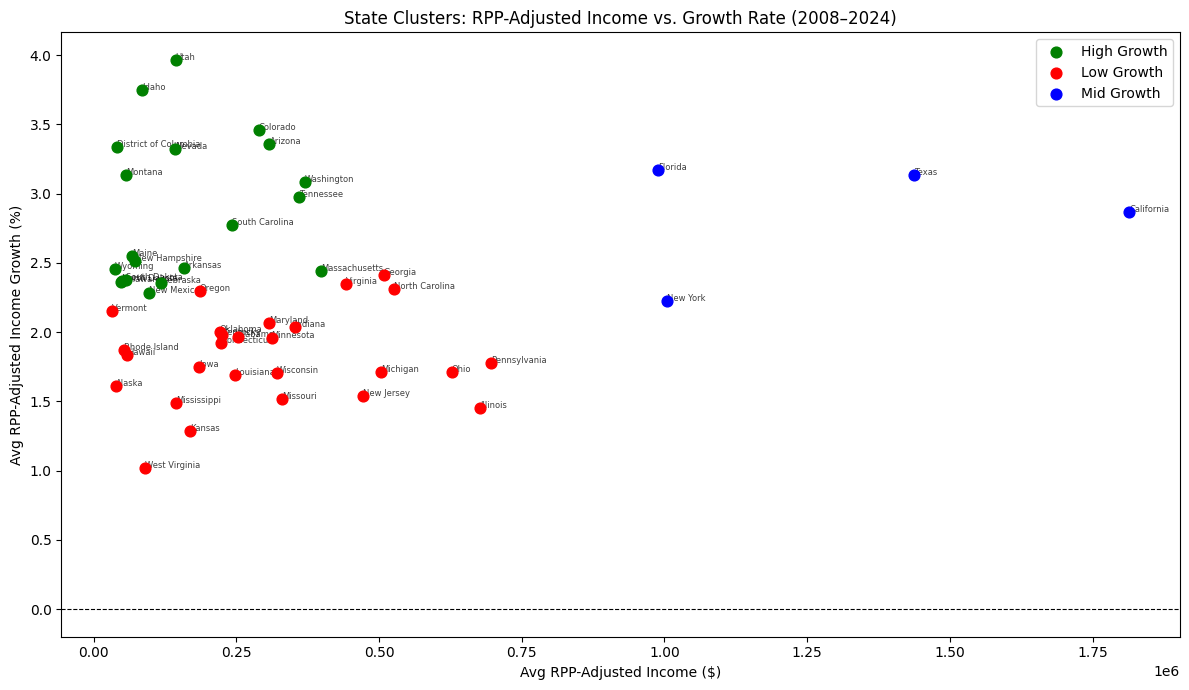

In [86]:
colors = {'Low Growth': 'red', 'Mid Growth': 'blue', 'High Growth': 'green'}

fig, ax = plt.subplots(figsize=(12, 7))

for label, group in state_summary.groupby('Cluster_Label'):
    ax.scatter(group['Avg_Adj_Income'], group['Avg_Growth'],
               color=colors[label], label=label, s=60, zorder=5)
    for _, row in group.iterrows():
        ax.annotate(row['State'], (row['Avg_Adj_Income'], row['Avg_Growth']),
                    fontsize=6, alpha=0.75)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Avg RPP-Adjusted Income ($)')
ax.set_ylabel('Avg RPP-Adjusted Income Growth (%)')
ax.set_title('State Clusters: RPP-Adjusted Income vs. Growth Rate (2008–2024)')
ax.legend()
plt.tight_layout()
plt.show()

The scatter plot displays three different groupings of states. The mid growth states (blue) are clustered to the right and have the highest RPP-adjusted incomes but with moderate growth rates, showing that the wealthiest states are growing more slowly in real terms. Meanwhile the high growth states (green) are clustered to the left and have lower adjusted incomes but are growing the fastest, indicating rapid real income gains. Finally, the low growth states (red) span a range of income levels but share the slowest growth rates, indicating the weakest gains in purchasing power over time.

In [90]:
state_summary.groupby('Cluster_Label')[['Avg_Growth']].mean().sort_values('Avg_Growth')

,Avg_Growth
Cluster_Label,
Low Growth,1.830597
Mid Growth,2.848670
High Growth,2.865736


High Growth states lead with an average annual growth rate of 2.87%, suggesting these states are gradually catching up in purchasing power. Mid Growth states grow at a nearly identical rate of 2.85%, however this is driven by a small number of very large states like California, Texas, Florida, and New York. Low Growth states stand out most, with only 1.83% annual growth,indicating that residents in these states are falling the furthest behind in real purchasing power over time.

## Research Question 2 Conclusion

Our state-level clustering analysis reveals clear disparities in how inflation affects different parts of the United States. The mid growth cluster (blue) consists of the four largest states by total income - California, Texas, Florida, and New York - which despite their wealth show only moderate real income growth, suggesting that high costs of living are eating into their gains. The high growth cluster (green) is dominated by Mountain West states like Utah, Idaho, Colorado, Arizona, and Nevada, along with several smaller Southern and New England states, indicating that these regions are seeing the strongest gains in purchasing power. The low growth cluster (red) is the most geographically diverse, containing many Midwest states like Ohio, Michigan, Illinois, and Wisconsin, as well as several traditional Southern states like Alabama, Mississippi, and Louisiana, and even some wealthy Northeastern states like Connecticut and New Jersey — suggesting that slow real income growth is not purely a poverty issue but a broader regional pattern. West Virginia stands out as a notable outlier, ranking last in both average adjusted income and real income growth, making it the state most severely impacted by inflation in our analysis.

In conclusion, certain states are indeed hit harder by inflation than others. Mountain West states are pulling ahead while much of the Midwest and parts of the South and Northeast are falling behind in real purchasing power over time.

## Overall Conclusion

This project investigated which groups are hit hardest by inflation in the United States across two different points: income level and geography. In Part 2, we found that inflation disproportionately impacts lower income households, with Quintile 1 being the only group to experience negative average real income growth over the 2006–2022 period, while higher income groups consistently maintained stronger purchasing power. In Part 3, we extended this analysis to the state level and found that geography plays a similarly important role. Mountain West states like Utah, Idaho, and Colorado saw the strongest real income gains, while much of the Midwest and parts of the South — particularly West Virginia — showed the weakest growth in purchasing power.

Taken together, these findings suggest that the burden of inflation is not equally shared, and can be worse for groups of lower income, and groups in certain states. Lower income households already struggling with reduced purchasing power are often concentrated in the same low growth states that are falling furthest behind. This reinforces the idea that inflation does not affect all Americans equally, and that the effects of inflation are felt most severely by those who are already the most economically vulnerable.

### Credit Listing

**Sanjana Devakumaran** *(sanjud)*
- Part 2: Researched relevant datasets and annotated/documented the code for clarity and readability
- Part 3: Added state-level analysis including RPP-adjusted income, z-score normalization, elbow method k selection, K-means clustering, and the scatter plot visual of state clusters. Added descriptions to visuals.

**Sanjna Rachakonda** *(sanjnarachakonda)*
- Part 2: Led the analysis, documented key findings, and contributed to additional data research
- Part 3: Worked with data analysis and interpretation, including connecting clustering results back to the research questions, explaining economic implications of income vs. growth trends, and writing the final conclusion

**Tommy Ayers** *(tlayers21)*
- Part 2: Identified and analyzed trends across income quintiles, joined data together, calculated real income and real income growth, and visualized real income across the different quintiles
- Part 3: Prepared and cleaned the state income and RPP datasets, merged them into a unified table, added overall conclusion, and polished the final notebook.

**Johnson Hwang** *(hjohnson22)*
- Part 2: Found the CPI and Income datasets, cleaned data, and revised the notebook based on Part 1 submission feedback
- Part 3: Helped find the State Income and State RPP datasets, documented data analysis procedures, and restructured the notebook to fit the QAC format